# Notebook Dedicated to Construct the Time Residual Distriburions of the Dataset 

In [1]:
import numpy as np
import glob
import os

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, ScalarFormatter
from matplotlib import font_manager

import seaborn as sn

# Load Data

In [2]:
main_dir = 'E:/Data/solars/solarnu_Realdata/2p2PPO/first_candidates/ratds/np_files/hit_residual_*.npy'

tres_min_cut = -10
tres_max_cut = 20

flist = glob.glob(main_dir)

time_res = np.array([])

for f_i in flist:
    time_res_i = np.load(f_i)
    time_res = np.append(time_res, time_res_i)

condition_cut = (time_res >= tres_min_cut) & (time_res <= tres_max_cut)

time_res = time_res[condition_cut]

# Time Residual Plot

In [3]:
save_path = 'figs/above_5_MeV_solar_results/'

font_style_title = {'family':'serif', 'weight': 'normal','color':'black','size':13}
font_style_axis= {'family':'serif', 'weight': 'normal','color':'black','size':12}
font_prop = font_manager.FontProperties(family=font_style_axis['family'], weight=font_style_axis['weight'], size=font_style_axis['size'])

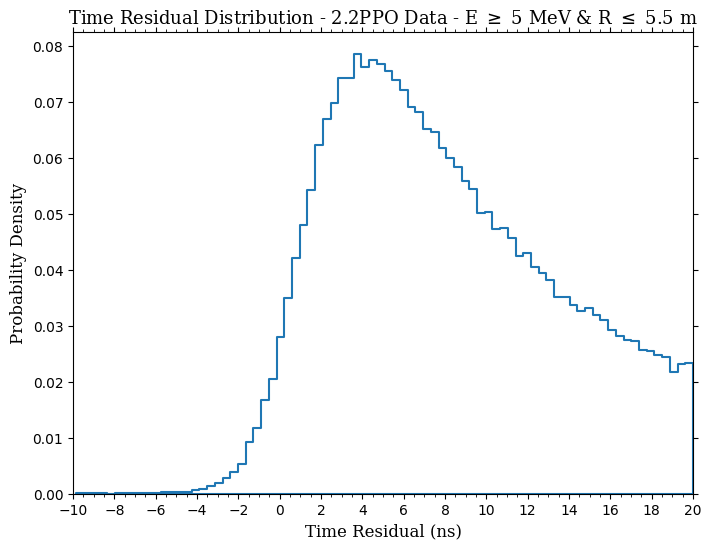

In [5]:
fig, ax = plt.subplots(figsize=(8,6))

bins = 80

sn.histplot(time_res, bins = bins, element = 'step', alpha = 0, linewidth = 1.5, stat = 'density')


#plt.yscale('log')

ax.xaxis.set_minor_locator(MultipleLocator(0.5))
ax.xaxis.set_major_locator(MultipleLocator(2))

ax.tick_params(which='minor', top=True, bottom=True, left=True, right=True)
ax.tick_params(which='major', top=True, bottom=True, left=True, right=True)

plt.ylabel('Probability Density', fontdict=font_style_axis)
plt.xlabel('Time Residual (ns)', fontdict=font_style_axis)
plt.title(rf'Time Residual Distribution - 2.2PPO Data - E $\geq$ 5 MeV & R $\leq$ 5.5 m', fontdict = font_style_title)

plt.xlim(tres_min_cut, tres_max_cut)

plt.savefig(save_path + f'time_residual_E_5_MeV_R_5.5_m.png', dpi=300, bbox_inches='tight')

plt.show()